In [569]:
import os
import pickle
import matplotlib.pyplot as plt
import sys
internal_MPCVSPD_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(internal_MPCVSPD_dir, '..'))
internal_PDC_dir = os.path.abspath(os.path.join(root_dir, '4_PD_Controllers'))
internal_MPC_dir = os.path.abspath(os.path.join(root_dir, '5_MPC_Controllers'))
internal_CP_dir = os.path.abspath(os.path.join(root_dir, '6_Common_Paramaters'))
internal_PDCWSM_dir = os.path.abspath(os.path.join(internal_PDC_dir, '1_Without_System_model'))
internal_MPCWSM_dir = os.path.abspath(os.path.join(internal_MPC_dir, '1_Without_System_model'))
sys.path.append(internal_CP_dir)
import Common_Params as CP

In [570]:
PD_controller_path = os.path.abspath(os.path.join(internal_PDCWSM_dir, 'store_results_data'))
MPC_controller_path = os.path.abspath(os.path.join(internal_MPCWSM_dir, 'store_results_data'))

In [571]:
for i, file in enumerate(os.listdir(PD_controller_path)):
    if file == 'times.pkl':
        with open(os.path.join(PD_controller_path, file), 'rb') as f:
            store_times_PD_Controller = pickle.load(f)
    elif file == 'separations.pkl':
        with open(os.path.join(PD_controller_path, file), 'rb') as f:
            store_seperations_PD_Controller = pickle.load(f)
    elif file == 'velocities.pkl':
        with open(os.path.join(PD_controller_path, file), 'rb') as f:
            store_velocities_PD_Controller = pickle.load(f)
    elif file  == 'accelerations.pkl':
        with open(os.path.join(PD_controller_path, file), 'rb') as f:
            store_accelerations_PD_Controller = pickle.load(f)
    elif file == 'detected_times.pkl':
        with open(os.path.join(PD_controller_path, file), 'rb') as f:
            store_detected_times_PD_Controller = pickle.load(f)
    elif file == 'start_reaction_times.pkl':
        with open(os.path.join(PD_controller_path, file), 'rb') as f:
            store_start_reaction_times_PD_Controller = pickle.load(f)
    else:
        print('ERROR')            

In [572]:
for i, file in enumerate(os.listdir(MPC_controller_path)):
    if file == 'times.pkl':
        with open(os.path.join(MPC_controller_path, file), 'rb') as f:
            store_times_MPC_Controller = pickle.load(f)
    elif file == 'separations.pkl':
        with open(os.path.join(MPC_controller_path, file), 'rb') as f:
            store_seperations_MPC_Controller = pickle.load(f)
    elif file == 'velocities.pkl':
        with open(os.path.join(MPC_controller_path, file), 'rb') as f:
            store_velocities_MPC_Controller = pickle.load(f)
    elif file  == 'accelerations.pkl':
        with open(os.path.join(MPC_controller_path, file), 'rb') as f:
            store_accelerations_MPC_Controller = pickle.load(f)
    elif file == 'detected_times.pkl':
        with open(os.path.join(MPC_controller_path, file), 'rb') as f:
            store_detected_times_MPC_Controller = pickle.load(f)
    elif file == 'start_reaction_times.pkl':
        with open(os.path.join(MPC_controller_path, file), 'rb') as f:
            store_start_reaction_times_MPC_Controller = pickle.load(f)
    else:
        print('ERROR')            

In [ ]:
def plot(store_times, store_accelerations, store_velocities, store_seperations, store_detected_times, store_start_reaction_times, Dr, Vp, title):
    fig, axes = plt.subplots(1, 3, figsize = (90, 25 * 1))                              # figsize = (width, height)
    font = 50
    border_thickness = 8.0
    
    for i in range(3):
        for spine in axes[i].spines.values():
            spine.set_linewidth(border_thickness)  # Set border (spine) thickness

    sri_1 = store_times[0].index(store_start_reaction_times[0])
    sri_2 = store_times[1].index(store_start_reaction_times[1])

    axes[0].plot(store_times[0], store_seperations[0], label = f'PD_Controller', color = 'red', linewidth = 6)
    axes[0].plot(store_times[1], store_seperations[1], label = f'MPC_Controller', color = 'blue', linestyle = '-.', linewidth = 4)
    axes[0].axvline(x = store_detected_times[0], color = 'black', linestyle = '-', label = 'Obstacle detected (PDC)', linewidth = 6)
    axes[0].axvline(x = store_start_reaction_times[0], color = "#4E13D8EB", linestyle = '-', label = 'Vehicle responds (PDC)', linewidth = 6)
    axes[0].axvline(x = store_detected_times[1], color = "#EA00FFFF", linestyle = '--', label = 'Obstacle detected (MPC)', linewidth = 4)
    axes[0].axvline(x = store_start_reaction_times[1], color = "#00FFEAFF", linestyle = '-.', label = 'Vehicle responds (MPC)', linewidth = 4)
    axes[0].plot(store_times[0][sri_1:], [CP.Dd + CP.Td * V * 5 / 18 for V in store_velocities[0][sri_1:]], label = f'Desired final seperation for PDC', color = 'green', linewidth = 6)
    axes[0].plot(store_times[1][sri_2:], [CP.Dd + CP.Td * V * 5 / 18 for V in store_velocities[1][sri_2:]], label = f'Desired final seperation for MPC', color = "#965102CC", linewidth = 8,linestyle = ':')
    axes[0].grid(True, linewidth = 4.0)
    axes[0].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[0].set_ylabel('Separation [m]', fontsize = font, fontweight = 'bold')
    # axes[0].set_title(title, fontsize = font, fontweight = 'bold')
    axes[0].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[0].legend(fontsize = font)

    axes[1].plot(store_times[0], store_velocities[0], label = f'PD_Controller', color = 'red', linewidth = 6)
    axes[1].plot(store_times[1], store_velocities[1], label = f'MPC_Controller', color = 'blue', linestyle = '-.', linewidth = 4)
    axes[1].axvline(x = store_detected_times[0], color = 'black', linestyle = '-', label = 'Obstacle detected (PDC)', linewidth = 6)
    axes[1].axvline(x = store_start_reaction_times[0], color = "#4E13D8EB", linestyle = '-', label = 'Vehicle responds (PDC)', linewidth = 6)
    axes[1].axvline(x = store_detected_times[1], color = "#EA00FFFF", linestyle = '--', label = 'Obstacle detected (MPC)', linewidth = 4)
    axes[1].axvline(x = store_start_reaction_times[1],color = "#00FFEAFF", linestyle = '-.', label = 'Vehicle responds (MPC)', linewidth = 4)
    axes[1].plot(store_times[0][sri_1:], [Vp * 18 / 5 for _ in range(len(store_velocities[0]))][sri_1:], label = f'Desired final velocity for PDC', color = 'green', linewidth = 6)
    axes[1].plot(store_times[1][sri_2:], [Vp * 18 / 5 for _ in range(len(store_velocities[1]))][sri_2:], label = f'Desired final velocity for MPC', color = "#965102CC", linewidth = 8,linestyle = ':')
    axes[1].grid(True, linewidth = 4.0)
    axes[1].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[1].set_ylabel('Velocity [km/hr]', fontsize = font, fontweight = 'bold')
    # axes[1].set_title(title, fontsize = font, fontweight = 'bold')
    axes[1].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[1].legend(fontsize = font)

    axes[2].plot(store_times[0], store_accelerations[0], label = f'PD_Controller', color = 'red', linewidth = 6)
    axes[2].plot(store_times[1], store_accelerations[1], label = f'MPC_Controller', color = 'blue', linestyle = '-.', linewidth = 4)
    axes[2].axvline(x = store_detected_times[0], color = 'black', linestyle = '-', label = 'Obstacle detected (PDC)', linewidth = 6)
    axes[2].axvline(x = store_start_reaction_times[0], color = "#4E13D8EB", linestyle = '-', label = 'Vehicle responds (PDC)', linewidth = 6)
    axes[2].axvline(x = store_detected_times[1], color = "#EA00FFFF", linestyle = '--', label = 'Obstacle detected (MPC)', linewidth = 4)
    axes[2].axvline(x = store_start_reaction_times[1], color = "#00FFEAFF", linestyle = '-.', label = 'Vehicle responds (MPC)', linewidth = 4)
    axes[2].grid(True, linewidth = 4.0)
    axes[2].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[2].set_ylabel('Acceleration [m/s^2]', fontsize = font, fontweight = 'bold')
    # axes[2].set_title(title, fontsize = font, fontweight = 'bold')
    axes[2].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[2].legend(fontsize = font)

    plt.show()

In [574]:
#titles = ['Cut in scenario (Scenario 1)', ' Slower preceding vehicle scenario (Scenario 2)', 'Complete stopping scenario (Scenario 3)', 'Cut in scenario (Scenario 1)']

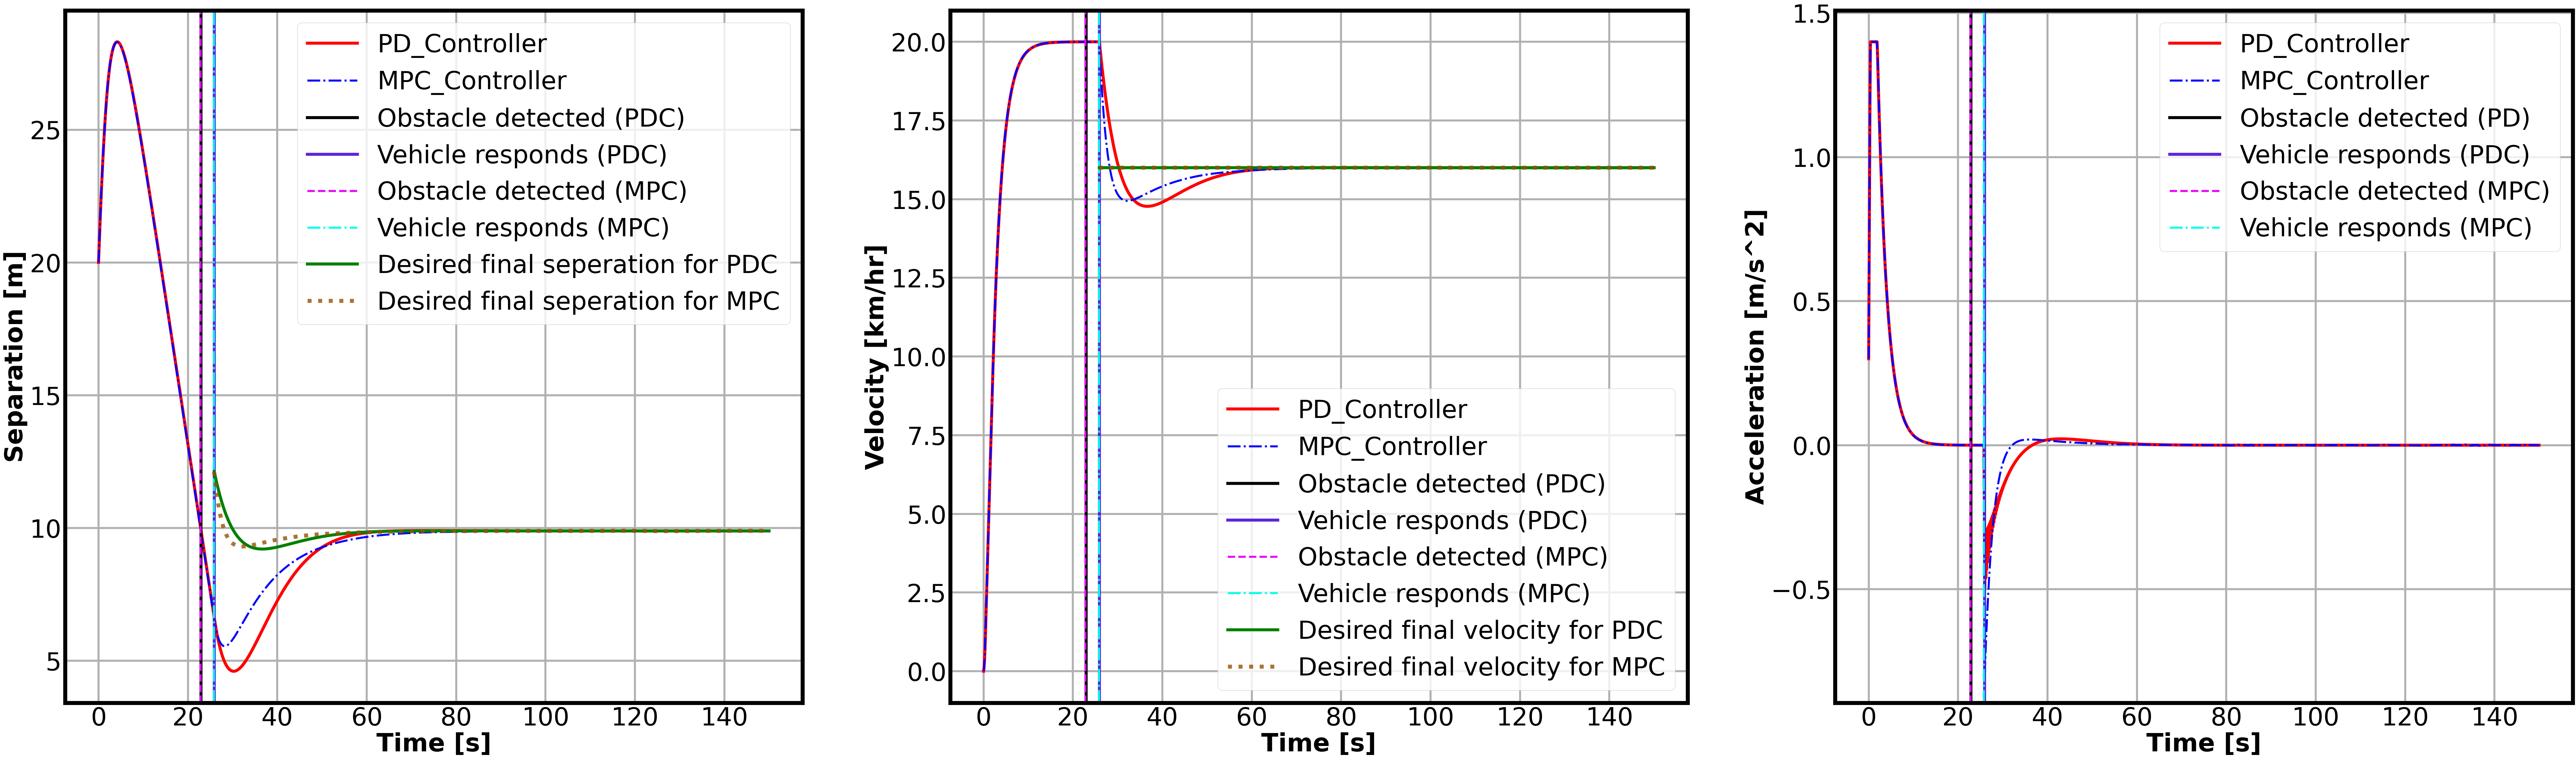

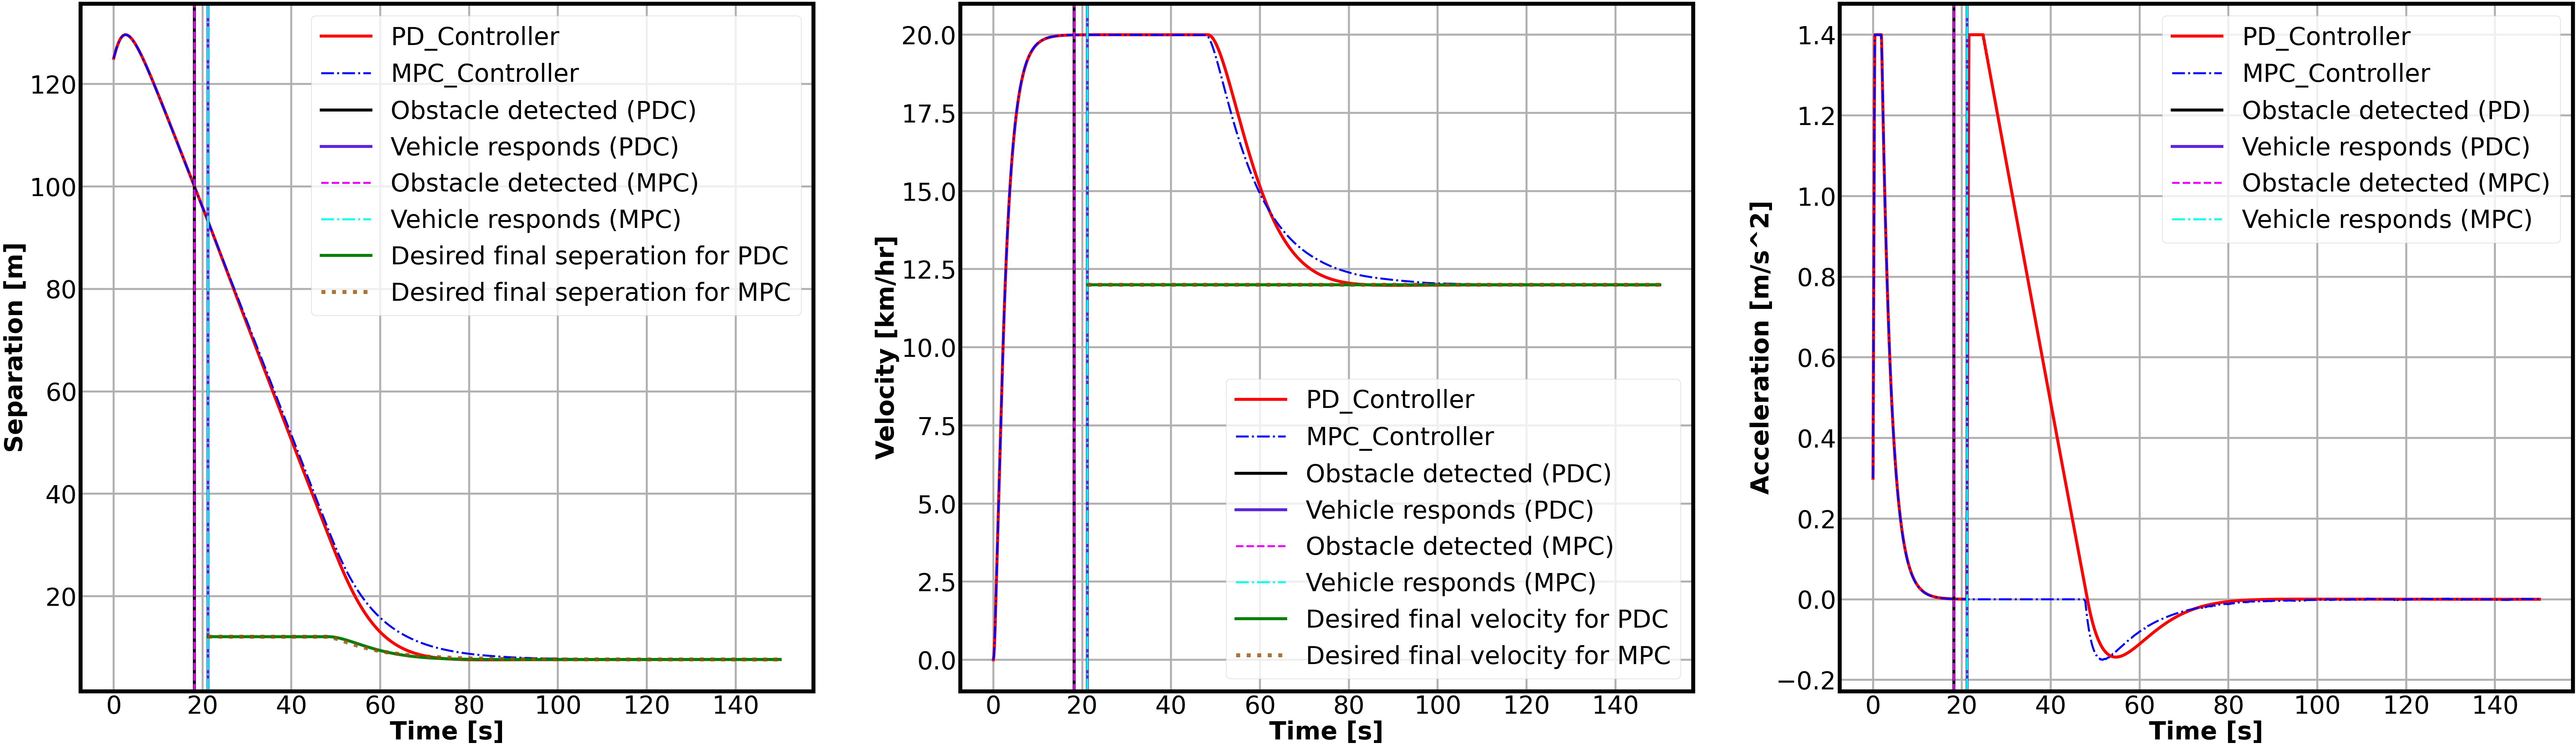

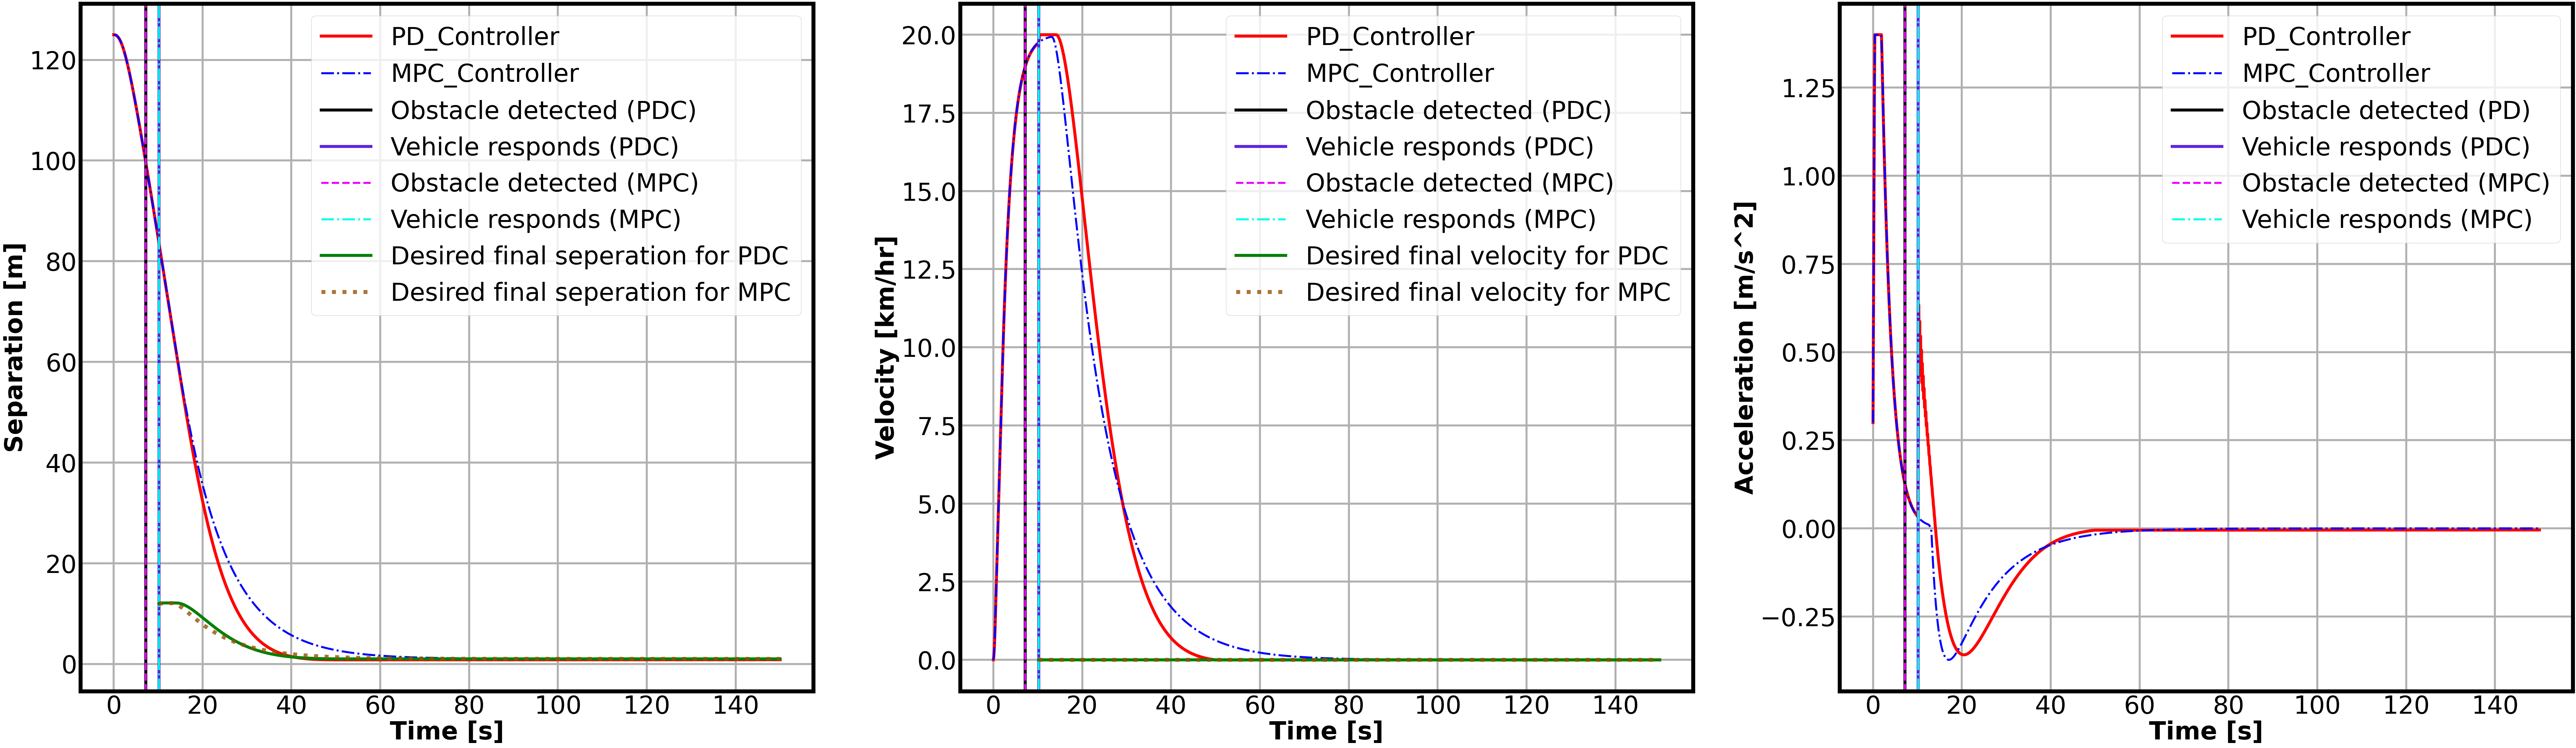

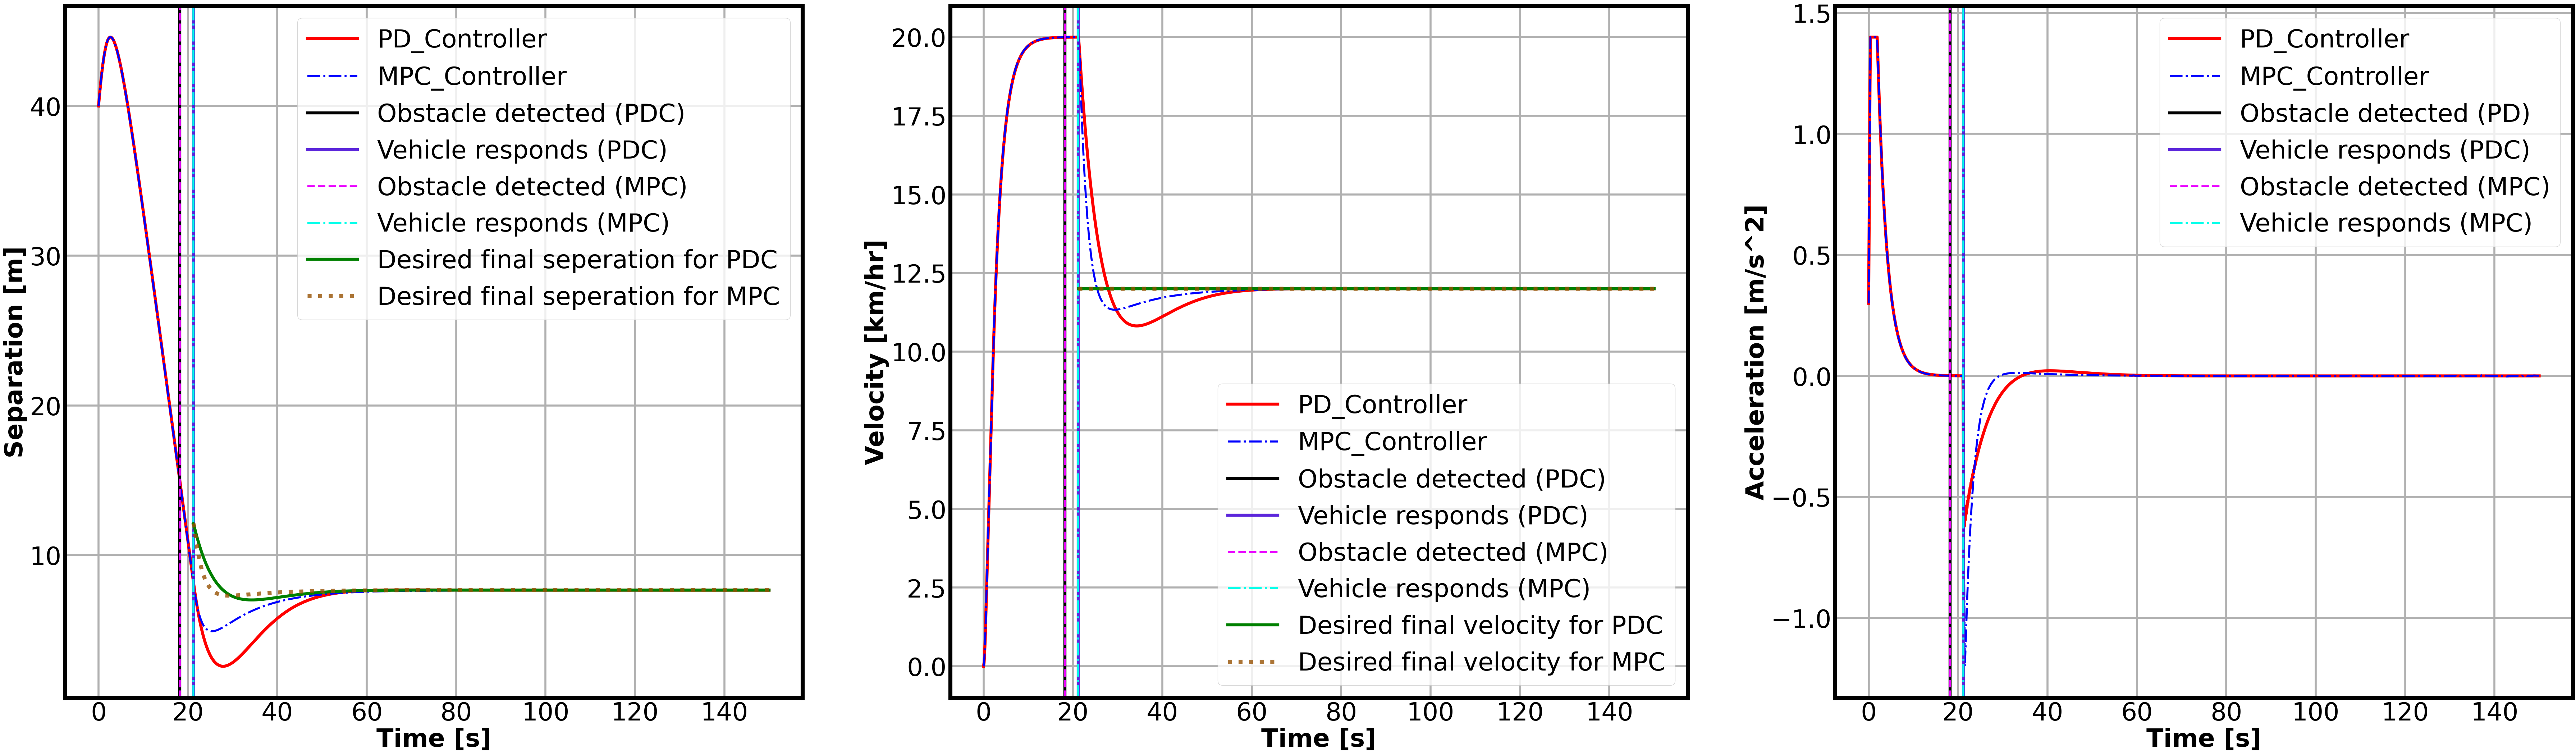

In [575]:
for i in range(len(store_times_PD_Controller)):
    plot([store_times_PD_Controller[i], store_times_MPC_Controller[i]], [store_accelerations_PD_Controller[i], store_accelerations_MPC_Controller[i]], [store_velocities_PD_Controller[i], store_velocities_MPC_Controller[i]], [store_seperations_PD_Controller[i], store_seperations_MPC_Controller[i]], [store_detected_times_PD_Controller[i], store_detected_times_MPC_Controller[i]], [store_start_reaction_times_PD_Controller[i], store_start_reaction_times_MPC_Controller[i]], CP.Drs[i], CP.Vps[i], titles[i])